In [1]:
from typing import Any

import pandas as pd
from wandb.apis.public.runs import Run

import numpy as np

import wandb
import math

import matplotlib.pyplot as plt

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs("graphcore/llama-mobile", filters={"config.name": "lr-sweep-v1"})

In [4]:
def cleanup_run(run: Run) -> dict[str, Any]:
    d = {}
    # TODO: Add quantisation settings

    d["batch_size"] = run.config["training"]["batch_size"]
    d["n_steps"] = run.config["training"]["n_steps"]
    d["beta1"] = run.config["training"]["optimiser"]["betas"][0]
    d["beta2"] = run.config["training"]["optimiser"]["betas"][1]
    d["lr_exponent"] = math.log2(run.config["training"]["optimiser"]["lr"])

    d["step_time"] = None
    d["loss"] = None

    if "loss" in run.summary:
        history = run.history(keys=["loss"])
        last_losses = history["loss"].dropna().tail(10).values
        final_loss = np.mean(last_losses)
        d["step_time"] = run.summary["step_time"]
        d["loss"] = final_loss

    return d

In [5]:
df = pd.DataFrame([cleanup_run(run) for run in runs])
df.sort_values(by="loss", ascending=True, inplace=True)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [6]:
df1 = df[df["n_steps"] <= 256]
df2 = df[df["n_steps"] > 256]

In [7]:
df1

,batch_size,n_steps,beta1,beta2,lr_exponent,step_time,loss
5,64,256,0.9,0.999,-15.0,16.939467,5.054520
7,64,256,0.9,0.999,-13.0,16.960585,5.179847
18,128,128,0.9,0.999,-12.0,31.845152,5.253797
19,128,128,0.9,0.999,-11.0,32.392111,5.523025
4,64,256,0.9,0.999,-16.0,16.917240,5.590578
6,64,256,0.9,0.999,-14.0,17.098871,5.602493
8,64,256,0.9,0.999,-12.0,16.935196,5.609420
17,128,128,0.9,0.999,-13.0,31.930060,5.621577
9,64,256,0.9,0.999,-11.0,16.906526,5.622945
3,64,256,0.9,0.999,-17.0,17.330064,5.655586


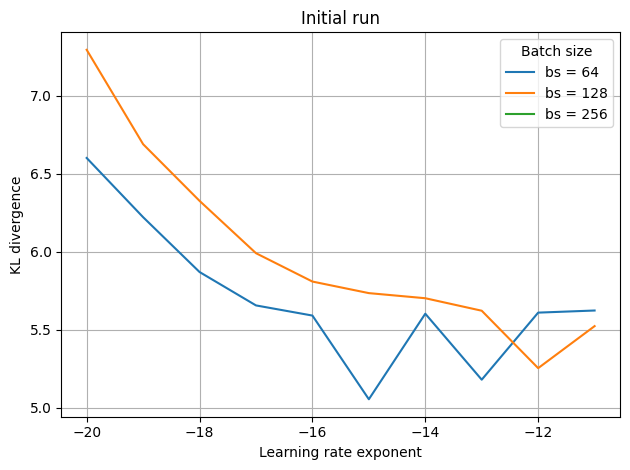

In [8]:
for bs, group in df1.groupby("batch_size"):
    group_sorted = group.sort_values('lr_exponent')
    plt.plot(group_sorted["lr_exponent"], group_sorted["loss"], label=f"bs = {bs}")
    
plt.title("Initial run")
plt.xlabel("Learning rate exponent")
plt.ylabel("KL divergence")
plt.legend(title="Batch size")
plt.grid(True)
plt.tight_layout()

In [9]:
df2

,batch_size,n_steps,beta1,beta2,lr_exponent,step_time,loss
38,64,384,0.9,0.999,-12.5,16.601531,4.220932
33,64,384,0.9,0.999,-15.0,16.582765,4.581898
37,64,384,0.9,0.999,-13.0,16.913920,4.626125
31,64,384,0.9,0.999,-16.0,16.922312,5.244203
32,64,384,0.9,0.999,-15.5,16.597319,5.499182
34,64,384,0.9,0.999,-14.5,16.878315,5.545580
30,64,384,0.9,0.999,-17.0,16.779221,5.550734
36,64,384,0.9,0.999,-13.5,16.997932,5.584463
35,64,384,0.9,0.999,-14.0,16.597363,5.626725


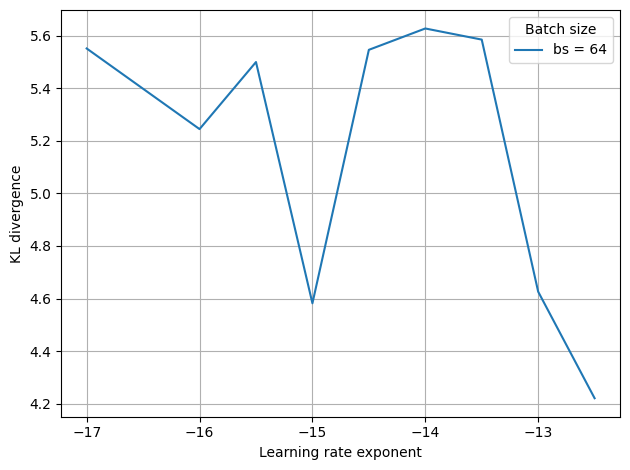

In [10]:
for bs, group in df2.groupby("batch_size"):
    group_sorted = group.sort_values('lr_exponent')
    plt.plot(group_sorted["lr_exponent"], group_sorted["loss"], label=f"bs = {bs}")
    
plt.xlabel("Learning rate exponent")
plt.ylabel("KL divergence")
plt.legend(title="Batch size")
plt.grid(True)
plt.tight_layout()